# 1. INTRODUCTION AND CONTEXT
The goal of this analysis is to investigate the disposable income around each Metro Station in Paris, to answer the following research questions:
-Whats the distirbution of average disposable income?
-Which Metro Line is the richest on average?
-Which Metro Line is the poorest on average?
-Which Metro Line ist the most unequal on average?

To answer this question, the following Data is used:
- Disposable Income Dataset of the French Gouverment: https://entrepot.recherche.data.gouv.fr/dataset.xhtml?persistentId=doi:10.57745/QRBINB ; The geotif raster was cropped and reprojected to a metric coordinate system using QGIS before 

- Shapefile of Stations, also provided by the french gouverment : https://www.data.gouv.fr/datasets/gares-et-stations-du-reseau-ferre-dile-de-france-par-ligne

- Shapefile of Metrolines, also provided by the french gouverment : https://www.data.gouv.fr/datasets/itineraires-de-metro-dans-openstreetmap

## METHODOLOGY
The methodology is to create a 300m buffer around the stations, using it as a simplyfied catchment area and calculate the spatial staitstic of average income. One has to note that also this approach is simplyfied, as it does not take into account the weight of each grid. So if a buffer touches 2 grids, it will be the unweighted average of both, no matter how much of which it touches. 

## STRUCTURE OF OUTCOMES 
The project has the following structure :
1. Introduction and Context
2. Imports
3. Data Processing
4. Data Analysis
       
    -4.1 Income Distribution

    -4.2 Grouping Stations per Line 

    -4.3 Income per Line
    
    -4.4 Unequality per Line

5. Regression for Line X
6. Conclusion

# 2. IMPORTS
Import Tools, Functions and Data

In [1]:
#Pathfinder
import sys
import os
sys.path.append(os.path.abspath(".."))

#Packages
import pandas as pd
import matplotlib.pyplot as plt

#Functions
from src.load_data import load_stations, load_income_grid
from src.raster_analysis import extract_mean_raster_value
from src.spatial import reproject_to_metric, create_buffers


In [2]:
#Import Station Data
stations = load_stations("../data/raw/Stations/emplacement-des-gares-idf/emplacement-des-gares-idf.shp")
stations.head()
stations = reproject_to_metric(stations)
stations = stations[stations["mode"] == "METRO"]
stations.shape

(405, 27)

## 3. DATA PROCESSING
Steps: Create the Buffers, Do the raster analysis,create Maps to control
Outcome: 

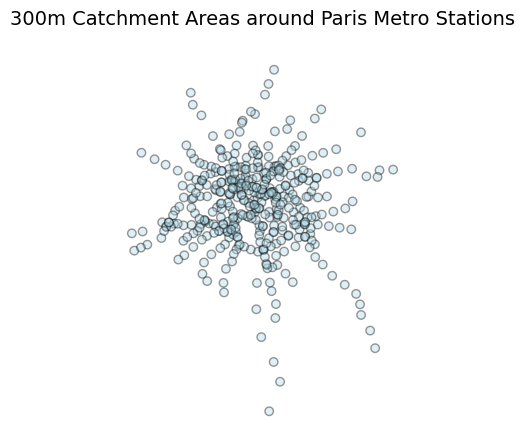

In [3]:
#CREATE THE BUFFERS:
station_buffers = create_buffers(stations, 300)

#CREATE A STATIC MAP
fig, ax = plt.subplots(figsize=(5, 5))

station_buffers.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black",
    color="lightblue"
)

ax.set_title("300m Catchment Areas around Paris Metro Stations", fontsize=14)
ax.set_axis_off()

plt.show()

#CREATE AN INTERACTIVE HTML MAP 
m = station_buffers.explore()
m.save("../outputs/1_MAP_Network.html")




In [4]:
#RASTERANALYSIS

income_raster_path = "../data/raw/TIF/FRA_disp_inc_2015_EPSG_2154_crop.tif"
station_buffers_income = extract_mean_raster_value(
    station_buffers,
    raster_path=income_raster_path,
    value_column="income_mean"
)

station_buffers_income["income_mean"].isna().sum()
station_buffers_income["income_mean"].describe()

count      405.000000
mean     32210.012566
std       5920.263834
min      18313.011719
25%      27469.699219
50%      32046.585938
75%      36723.921875
max      44404.005208
Name: income_mean, dtype: float64

PLAUSIBILITY CHECK

In [12]:
#10 richest Stations
top_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=False
).head(10)

top_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
214,Monceau,2,44404.005208
1220,Villiers,2,43928.445312
476,Villiers,3,43928.445312
1114,Malesherbes,3,43893.585938
728,Courcelles,2,43458.015625
835,Ternes,2,43458.015625
856,Jasmin,9,42903.179688
1121,Pont de Neuilly,1,42334.253906
625,Michel Ange-Auteuil,9,42263.179688
861,Michel Ange-Auteuil,10,42263.179688


In [11]:
# 10 Poorest Stations
bottom_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=True
).head(10)

bottom_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
465,Aimé Césaire,12,18313.011719
724,Mairie d'Aubervilliers,12,18417.355469
432,Front Populaire,12,19201.949219
937,Fort d'Aubervilliers,7,19592.882812
934,La Courneuve 8 Mai 1945,7,19598.752604
1172,Aubervilliers Pantin - Quatre Chemins,7,19958.837240
611,Saint-Denis - Porte de Paris,13,20616.679688
612,Saint-Denis - Université,13,20719.195312
227,Basilique de Saint-Denis,13,20913.832031
1097,Les Courtilles,13,21405.867188


Since the richest stations are concentrated in the inner northwest of Paris and the poorest stations around the north-eastern banlieu, the result seems to be plausibel 

# 4. Analysis
## 4.1 Income Distribution
xxxxxxx

In [13]:
#DISTIRBUTION, HOW MANY HAVE HOW MANY GRID CELLS
#DSITIRBUTION: HOW MANY IN WHICH INTERVALL
#GENERAL HEATMAP With the whole network in the intervall from above

## 4.2 Grouping Stations by Line
#SUMMARY STAT : HOW MANY STATIONS PER LINE

## 4.3 Income per Line
#Income per Line in Order


## 4.3 Unequality per Line
#Unequality per Line
#Interpretation